V2 Model 
V1 was Liner SVM 

In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

C:\Users\shree\AppData\Roaming\Python\Python311\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


In [2]:
import gc

def clear_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

clear_gpu()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [4]:
# Load datasets
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

# Display shapes
print("Training Set Shape:", train_df.shape)
print("Testing Set Shape:", test_df.shape)


# Preview data
train_df.head()

Training Set Shape: (5279, 4)
Testing Set Shape: (2924, 3)


,unique_hash,text,drug,sentiment
0,2e180be4c9214c1f5ab51fd8cc32bc80c9f612e0,Autoimmune diseases tend to come in clusters. ...,gilenya,2
1,9eba8f80e7e20f3a2f48685530748fbfa95943e4,I can completely understand why you’d want to ...,gilenya,2
2,fe809672251f6bd0d986e00380f48d047c7e7b76,Interesting that it only targets S1P-1/5 recep...,fingolimod,2
3,bd22104dfa9ec80db4099523e03fae7a52735eb6,"Very interesting, grand merci. Now I wonder wh...",ocrevus,2
4,b227688381f9b25e5b65109dd00f7f895e838249,"Hi everybody, My latest MRI results for Brain ...",gilenya,1


In [5]:
import re

def clean_text(text):
    text = str(text).lower()

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove non letters/numbers
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [6]:
train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

In [7]:
# Dataset information
train_df.info()

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nDuplicate Rows:", train_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   unique_hash  5279 non-null   object
 1   text         5279 non-null   object
 2   drug         5279 non-null   object
 3   sentiment    5279 non-null   int64 
dtypes: int64(1), object(3)
memory usage: 165.1+ KB

Missing Values:
unique_hash    0
text           0
drug           0
sentiment      0
dtype: int64

Duplicate Rows: 0


In [8]:
print(train_df["sentiment"].value_counts())

print("\nPercentage Distribution:")
print(train_df["sentiment"].value_counts(normalize=True) * 100)

sentiment
2    3825
1     837
0     617
Name: count, dtype: int64

Percentage Distribution:
sentiment
2    72.456905
1    15.855276
0    11.687820
Name: proportion, dtype: float64


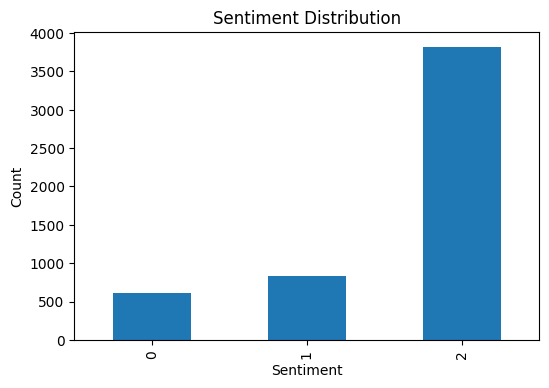

In [9]:
import matplotlib.pyplot as plt

train_df["sentiment"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [10]:
train_df["review_length"] = train_df["text"].astype(str).apply(len)

print(train_df["review_length"].describe())

count     5279.000000
mean      1952.334912
std       4480.818941
min          5.000000
25%        401.000000
50%        776.000000
75%       1644.000000
max      83550.000000
Name: review_length, dtype: float64


In [11]:
# Display a few random reviews
train_df[["drug", "text", "sentiment"]].sample(5, random_state=42)

,drug,text,sentiment
8,fingolimod,why do you think that fingolimod was such a mi...,1
1580,cladribine,lemtrada is for any form of ms with relapses r...,2
544,stelara,i wonder if anyone has ever combined two biolo...,2
4885,tarceva,i was diagnosed with stage 4 adeno lung cancer...,2
3941,entyvio,here s the latest update my husband certainly ...,1


In [12]:
MODEL_NAME = "microsoft/deberta-v3-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

C:\Users\shree\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [13]:
train_df = train_df.dropna(subset=["text", "sentiment"])

train_df = train_df.drop_duplicates()

train_df["text"] = train_df["text"].str.strip()

train_df["combined_text"] = (
    "Drug: "
    + train_df["drug"].fillna("")
    + " Review: "
    + train_df["text"]
)

test_df["combined_text"] = (
    "Drug: "
    + test_df["drug"].fillna("")
    + " Review: "
    + test_df["text"]
)

print(train_df.shape)

(5279, 6)


In [14]:
sample_text = train_df.loc[0, "combined_text"]

encoded = tokenizer(sample_text)

print("Original Review:\n")
print(sample_text)

print("\nToken IDs:")
print(encoded["input_ids"])

print("\nAttention Mask:")
print(encoded["attention_mask"])

Original Review:

Drug: gilenya Review: autoimmune diseases tend to come in clusters as for gilenya if you feel good don t think about it it won t change anything but waste your time and energy i m taking tysabri and feel amazing no symptoms other than dodgy color vision but i ve had it since always so don t know and i don t know if it will last a month a year a decade ive just decided to enjoy the ride no point in worrying

Token IDs:
[1, 7822, 294, 70772, 1319, 4746, 3209, 294, 24458, 4253, 2670, 264, 488, 267, 13891, 283, 270, 70772, 1319, 4746, 337, 274, 551, 397, 418, 1941, 428, 314, 278, 278, 722, 1941, 575, 784, 304, 2150, 290, 326, 263, 843, 584, 1917, 787, 32976, 268, 56529, 263, 551, 1201, 363, 2935, 340, 354, 40587, 1163, 2345, 304, 584, 10891, 330, 278, 515, 489, 324, 418, 1941, 391, 263, 584, 418, 1941, 391, 337, 278, 296, 437, 266, 788, 266, 395, 266, 3369, 584, 415, 348, 1216, 264, 929, 262, 2224, 363, 582, 267, 9997, 2]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [15]:
token_lengths = train_df["text"].apply(
    lambda x: len(tokenizer.encode(str(x), add_special_tokens=True))
)

print(token_lengths.describe())

count     5279.000000
mean       377.833681
std        822.503461
min          3.000000
25%         87.000000
50%        163.000000
75%        331.000000
max      14990.000000
Name: text, dtype: float64


In [16]:
MAX_LENGTH = 512
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["sentiment"],
    random_state=SEED
)

print("Training Samples :", len(train_data))
print("Validation Samples:", len(val_data))

Training Samples : 4223
Validation Samples: 1056


In [17]:
train_dataset = Dataset.from_pandas(train_data.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_data.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['unique_hash', 'text', 'drug', 'sentiment', 'review_length', 'combined_text'],
    num_rows: 4223
})
Dataset({
    features: ['unique_hash', 'text', 'drug', 'sentiment', 'review_length', 'combined_text'],
    num_rows: 1056
})


In [18]:
def tokenize_function(examples):
    encoding = tokenizer(examples["combined_text"], truncation=False)
    cls_id, sep_id = tokenizer.cls_token_id, tokenizer.sep_token_id
    keep = MAX_LENGTH - 2

    new_ids, new_mask = [], []
    for ids in encoding["input_ids"]:
        core = ids[1:-1]
        if len(core) > keep:
            head_len = keep // 2
            core = core[:head_len] + core[-(keep - head_len):]
        ids = [cls_id] + core + [sep_id]
        new_ids.append(ids)
        new_mask.append([1] * len(ids))

    encoding["input_ids"] = new_ids
    encoding["attention_mask"] = new_mask
    encoding.pop("token_type_ids", None)

    if "sentiment" in examples:
        encoding["labels"] = examples["sentiment"]
    return encoding

In [19]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/4223 [00:00<?, ? examples/s]

Map:   0%|          | 0/1056 [00:00<?, ? examples/s]

Map:   0%|          | 0/2924 [00:00<?, ? examples/s]

In [20]:

print(train_dataset[0])

{'unique_hash': '9b84bdc71e3ed1aa425cde056387276d741c3689', 'text': 'what was your mom s actual diagnosis surgery was never an option given to my uncle but we found out he had it after going to the er because he was having difficulty breathing and started coughing up blood they did treat him for pnumonia but after an mri they came back and said he had cancer the mass was on his airway later we were told it was stage iv inoperable and the only thing they could do was to try and treat it so radiation came first which did help lift the mass of the airway and he was able to breathe without oxygen eventually now he is doing the 2 different chemo s with keytruda he goes every friday next week will be month 2 so my question is is this going to help him to have quality of life or just prolonging his life can this actually cure or stop the cancer even though they said it is incurable also since i am new is this the correct way to respond on a post were it says quote', 'drug': 'keytruda', 'senti

In [21]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

val_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

In [22]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained(
    MODEL_NAME, num_labels=3,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1
)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, config=config)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [24]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "macro_f1": f1,
        "precision": precision,
        "recall": recall,
    }

In [25]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [26]:
training_args = TrainingArguments(
    output_dir="./deberta_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=16,
    eval_accumulation_steps=4,
    gradient_checkpointing=True,
    num_train_epochs=6,
    weight_decay=0.05,
    label_smoothing_factor=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=4
)

In [27]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3
)

In [28]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn.functional as F
from transformers import Trainer

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data["sentiment"]),
    y=train_data["sentiment"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

class CustomTrainer(Trainer):

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):

        labels = inputs.pop("labels")

        outputs = model(**inputs)

        loss = F.cross_entropy(
            outputs.logits,
            labels,
            weight=class_weights.to(model.device)
        )

        return (loss, outputs) if return_outputs else loss

In [29]:
trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping]
)

In [30]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Precision,Recall
1,1.091900,0.997752,0.614583,0.485538,0.473385,0.512730
2,0.879200,0.864511,0.497159,0.474672,0.512361,0.617947
3,0.745700,0.816341,0.604167,0.549887,0.551142,0.651794
4,0.531100,0.797929,0.585227,0.548052,0.550110,0.694276
5,0.456900,0.850006,0.637311,0.579175,0.559020,0.688579
6,0.391900,0.862847,0.651515,0.588411,0.564628,0.687566


TrainOutput(global_step=792, training_loss=0.6812186289315272, metrics={'train_runtime': 1877.9882, 'train_samples_per_second': 13.492, 'train_steps_per_second': 0.422, 'total_flos': 3318369799211136.0, 'train_loss': 0.6812186289315272, 'epoch': 6.0})

In [31]:
from sklearn.metrics import classification_report

pred = trainer.predict(val_dataset)

y_pred = pred.predictions.argmax(axis=1)
y_true = pred.label_ids

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.37      0.67      0.48       123
           1       0.43      0.77      0.56       168
           2       0.89      0.62      0.73       765

    accuracy                           0.65      1056
   macro avg       0.56      0.69      0.59      1056
weighted avg       0.76      0.65      0.67      1056



In [32]:
from sklearn.metrics import f1_score, accuracy_score

class_counts = train_data["sentiment"].value_counts().sort_index().values
log_prior = np.log(class_counts / class_counts.sum())

logits = pred.predictions
best_tau, best_f1 = 0, 0
for tau in [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]:
    adjusted = logits - tau * log_prior
    y_pred_adj = adjusted.argmax(axis=1)
    f1 = f1_score(y_true, y_pred_adj, average="macro")
    print(f"tau={tau}: macro F1={f1:.4f}, acc={accuracy_score(y_true, y_pred_adj):.4f}")
    if f1 > best_f1:
        best_f1, best_tau = f1, tau

print("Best tau:", best_tau)

tau=0.25: macro F1=0.5637, acc=0.6165
tau=0.5: macro F1=0.5445, acc=0.5843
tau=0.75: macro F1=0.5135, acc=0.5407
tau=1.0: macro F1=0.4778, acc=0.4943
tau=1.25: macro F1=0.4453, acc=0.4517
tau=1.5: macro F1=0.4086, acc=0.4053
tau=1.75: macro F1=0.3541, acc=0.3428
tau=2.0: macro F1=0.3108, acc=0.2964
Best tau: 0.25


In [33]:
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")w

('./final_model\\tokenizer_config.json',
 './final_model\\special_tokens_map.json',
 './final_model\\spm.model',
 './final_model\\added_tokens.json',
 './final_model\\tokenizer.json')